### Generate Data by Varying $\omega$ (2-D FEA Beam with Elliptic Hole)

In [1]:
# Imports
import os, sys
import numpy as np

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
from beam_fea_v2_pointload_shared_mesh import BeamFEAPointLoad
from sobol import generate_sobol
from sensor_processing_v2 import sensor_processing
from yaml_processor import load_config, save_config
from data_processing import load_dataset, save_dataset

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
# Load or Create New Data
load_init = True
load_train = True
load_val = True
load_test = True

In [3]:
# Same omega range as the 1-D omega example
#T_range = np.array([(2/((4**2)*np.pi), 2/np.pi)])  # Time period

#w_range = 2*np.pi/(T_range) # Omega
w_range = 2*np.pi*np.array([[60, 100]]) # Omega
T_range = 2*np.pi/w_range # Time period
tau_param = np.min(T_range)/5 # Impulse width
max_dt = tau_param/5 # dt

param_ranges = [w_range[0]]

nt = 100 # config_global["data"]["nt"] # number of time steps
nx = config_global["data"]["nx"] # number of spatial points

n_init = 16 # number of initial full space dataset
n_train = 64 # number of training params
n_val = 16 # number of validation params
n_test = 128 # number of test params

# Time vector
t = np.linspace(0, max_dt * nt, nt + 1)

# FEA solver with fixed hole (a=0.08, b=0.025)
fea = BeamFEAPointLoad(mesh_json_path='beam_ellipse_shared.json')
noise_std = 0.001

print(f"omega range: {w_range}")
print(f"tau: {tau_param}, max_dt: {max_dt}")
print(f"nt: {nt}, nx: {nx}")

omega range: [[376.99111843 628.31853072]]
tau: 0.002, max_dt: 0.0004
nt: 100, nx: 101


##### Helper: solve for one omega value

In [4]:
def solve_one(omega_val):
    """Solve for one omega and return (W, Wdot, ft) in the right shapes."""
    # W, Wdot, ft, mesh, ib, W_full, Wdot_full = fea.solve(
    #     omega=float(omega_val),
    #     tau=tau_param,
    #     nt=nt,
    #     n_top_pts=nx,
    #     t=t,
    # )

    #tau_param = 2*np.pi/(10*omega_val) # Impulse width, 1/5th of the period
    
    W, Wdot, ft, mesh, ib, W_full, Wdot_full, t1p,t, W_full_all, Wdot_full_all = fea.solve(
        omega=float(omega_val),
        tau=tau_param,
        nt=nt,          # steps per period
        n_periods=20,    # simulate 20 periods, return the last one
        F0=1e4,
        beta_d=1e-3,
        load_type='pulse',

        # t=t
    )


    return W, Wdot, ft, mesh, ib, W_full, Wdot_full, t1p,t, W_full_all, Wdot_full_all

##### Generate Initial Full Space Data

In [5]:
#n_init = 1
mesh_list = []
ib_list = []

In [6]:
param_init = generate_sobol(1, n_init, param_ranges)

In [7]:
fea._assemble()

Transforming over 1000 vertices to C_CONTIGUOUS.
Transforming over 1000 elements to C_CONTIGUOUS.


In [8]:
if load_init:
    SS_init, param_init, ft_init, _, _, _ = load_dataset(os.path.join(output_dir, "datasets/Init"), normalize=False)
else:
    param_init = generate_sobol(1, n_init, param_ranges)
    SS_init = np.zeros([n_init, 2, nt, fea._mesh.p.shape[1]*2])
    ft_init = np.zeros([n_init, nt, 2])  # [F(t), omega]

    for i in range(n_init):
        print(f"Init - {i+1}/{n_init}")
        _, _, ft_init[i], msh, ib, SS_init[i, 0], SS_init[i, 1], t1p, _, W_full_all, Wdot_full_all = solve_one(param_init[i])
        # solve_one(param_init[i])
        mesh_list.append(msh)
        ib_list.append(ib)
        
    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Init"), SS_init, param_init, ft_init, cluster=None)

In [9]:
import matplotlib.pyplot as plt

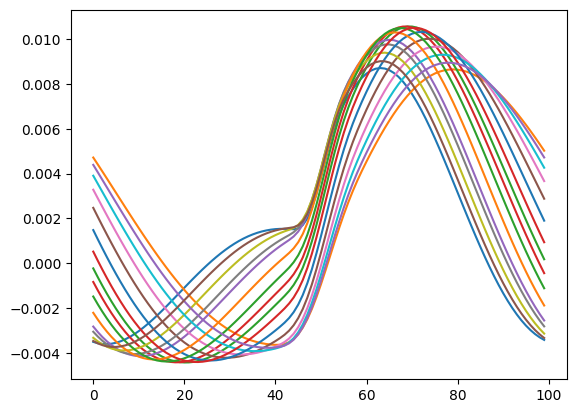

In [10]:
plt.figure()
plt.plot(SS_init[:, 0, :, 101].T)
plt.show()

In [11]:
from generate_vtk import save_vtk_solution
from skfem import *

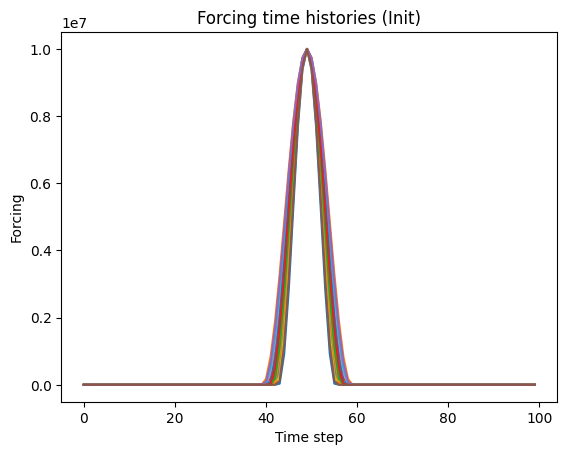

In [12]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(ft_init[:, :, 0].T)
plt.ylabel("Forcing")
plt.xlabel("Time step")
plt.title("Forcing time histories (Init)")
plt.show()

##### Find Optimal Sensor Locations

The preferred number of sensors is: 44


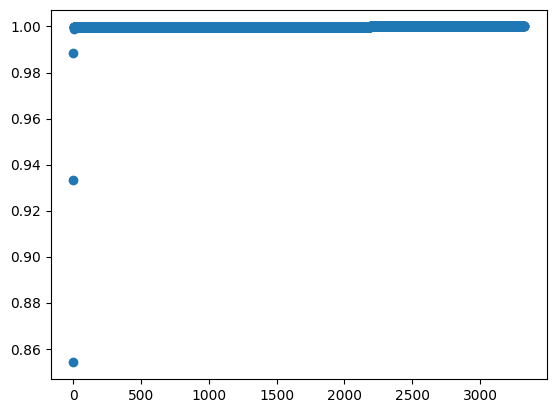

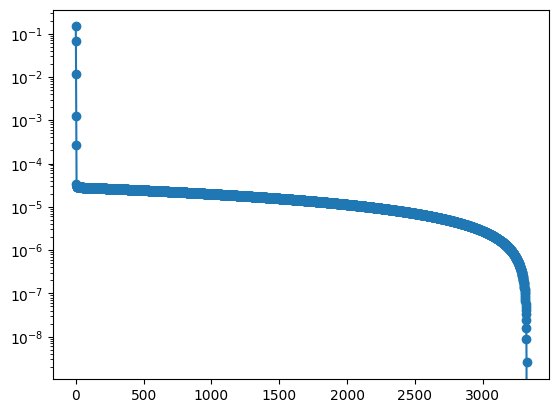

In [13]:
# Initialize sensor locator
sp = sensor_processing(SS_init[:, 1], config_global)
sp.perform_svd()
sp.plot_singular(err_cap=0.000028)

#### Choose number of sensors

In [14]:
num_sensors = 50

In [15]:
# Apply sensor locator
sp.opt_sensor_loc(num_sensors, fill_gaps=False)
# Save setup
sp.save(output_dir)

Sensor nodes are [   2    4   15   21   50   58   84  127  156  185  192  221  290  315
  335  343  352  376  428  464  517  524  609  664  683  687  753  891
  913  942  958  976 1036 1249 1261 1310 1354 1398 1600 2080 2127 2224
 2420 2562 2824 2835 2920 2925 2948 2999]


In [47]:
import matplotlib.pyplot as plt

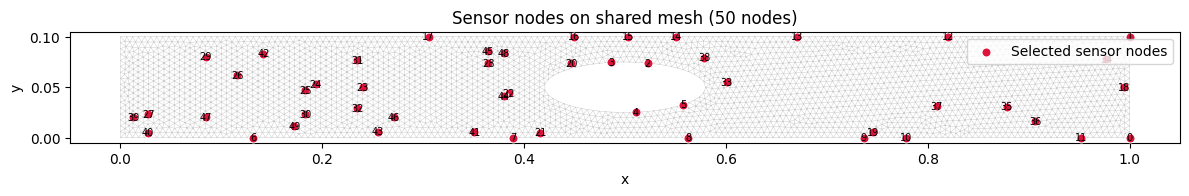

In [16]:
mesh = fea._mesh if fea._mesh is not None else mesh_list[-1]
sensor_nodes = np.asarray(sp.sensor_placement, dtype=int)

if config_global["sensors"].get("sensor_mode", "scalar") != "vector_nodes":
    raise ValueError("This plot expects sensor_mode='vector_nodes'.")

x = mesh.p[0]
y = mesh.p[1]
tri = mesh.t.T

plt.figure(figsize=(12, 3.5))
plt.triplot(x, y, tri, color="0.80", linewidth=0.35, zorder=1)
plt.scatter(
    x[sensor_nodes],
    y[sensor_nodes],
    s=42,
    c="crimson",
    edgecolors="white",
    linewidths=0.7,
    zorder=3,
    label="Selected sensor nodes",
)

for idx, node in enumerate(sensor_nodes):
    plt.text(
        x[node],
        y[node],
        str(idx),   # change to str(node) if you want mesh node IDs instead
        fontsize=7,
        ha="center",
        va="center",
        color="black",
        zorder=4,
    )

plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Sensor nodes on shared mesh ({len(sensor_nodes)} nodes)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


C:\Users\haida\AppData\Local\Temp\ipykernel_10328\2489420390.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  [f"Omega {int(param_init[i])}" for i in range(n_init)],


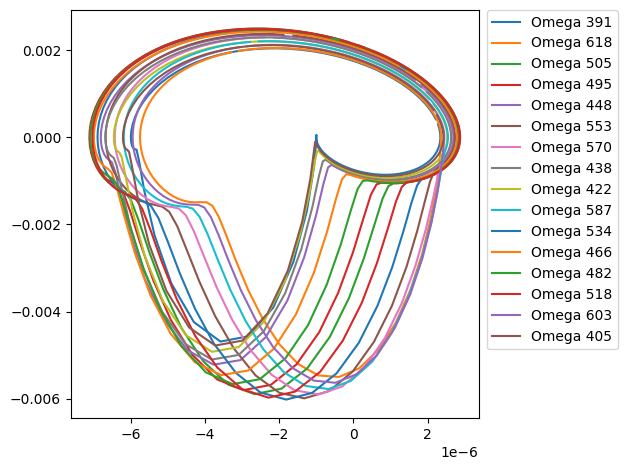

In [49]:
fig, ax = plt.subplots()

ax.plot(SS_init[:, 0, :, 1000].T, SS_init[:, 1, :, 1000].T)

ax.legend(
    [f"Omega {int(param_init[i])}" for i in range(n_init)],
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0
)

plt.tight_layout()
plt.show()

In [50]:
# Save configuration
config_global["data"]["param_bounds"]["w"] = np.sort(w_range[0]).tolist()
config_global["sensors"]["num_sensors"] = num_sensors
save_config(config_file, config_global)

#### Generate Training Data

In [51]:
if load_train:
    SS_train, param_train, ft_train, _, _, _ = load_dataset(os.path.join(output_dir, "datasets/Train"), normalize=False)
else:
    param_train = generate_sobol(1, n_train, param_ranges)
    SS_train = np.zeros([n_train, 2, nt, fea._mesh.p.shape[1]*2])
    ft_train = np.zeros([n_train, nt, 2])  # [F(t), omega]

    for i in range(n_train):
        print(f"Train - {i+1}/{n_train}")
        _, _, ft_train[i], msh, ib, SS_train[i, 0], SS_train[i, 1], t1p,t, W_full_all, Wdot_full_all = solve_one(param_train[i])
        # solve_one(param_train[i])
        mesh_list.append(msh)
        ib_list.append(ib)
        
    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Train"), SS_train, param_train, ft_train, cluster=None)

Train - 1/64


C:\Users\haida\AppData\Local\Temp\ipykernel_10328\4209413923.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  omega=float(omega_val),


Train - 2/64
Train - 3/64
Train - 4/64
Train - 5/64
Train - 6/64
Train - 7/64
Train - 8/64
Train - 9/64
Train - 10/64
Train - 11/64
Train - 12/64
Train - 13/64
Train - 14/64
Train - 15/64
Train - 16/64
Train - 17/64
Train - 18/64
Train - 19/64
Train - 20/64
Train - 21/64
Train - 22/64
Train - 23/64
Train - 24/64
Train - 25/64
Train - 26/64
Train - 27/64
Train - 28/64
Train - 29/64
Train - 30/64
Train - 31/64
Train - 32/64
Train - 33/64
Train - 34/64
Train - 35/64
Train - 36/64
Train - 37/64
Train - 38/64
Train - 39/64
Train - 40/64
Train - 41/64
Train - 42/64
Train - 43/64
Train - 44/64
Train - 45/64
Train - 46/64
Train - 47/64
Train - 48/64
Train - 49/64
Train - 50/64
Train - 51/64
Train - 52/64
Train - 53/64
Train - 54/64
Train - 55/64
Train - 56/64
Train - 57/64
Train - 58/64
Train - 59/64
Train - 60/64
Train - 61/64
Train - 62/64
Train - 63/64
Train - 64/64


#### Generate Validation Data

In [52]:
if load_val:
    SS_val, param_val, ft_val, _, _, _ = load_dataset(os.path.join(output_dir, "datasets/Val"), normalize=False)
else:
    param_val = generate_sobol(1, n_val, param_ranges)
    SS_val = np.zeros([n_val, 2, nt, fea._mesh.p.shape[1]*2])
    ft_val = np.zeros([n_val, nt, 2])  # [F(t), omega]

    for i in range(n_val):
        print(f"Val - {i+1}/{n_val}")
        _, _, ft_val[i], msh, ib, SS_val[i, 0], SS_val[i, 1], t1p,t, W_full_all, Wdot_full_all = solve_one(param_val[i])
        # solve_one(param_val[i])
        mesh_list.append(msh)
        ib_list.append(ib)
        
    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Val"), SS_val, param_val, ft_val, cluster=None)

Val - 1/16


C:\Users\haida\AppData\Local\Temp\ipykernel_10328\4209413923.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  omega=float(omega_val),


Val - 2/16
Val - 3/16
Val - 4/16
Val - 5/16
Val - 6/16
Val - 7/16
Val - 8/16
Val - 9/16
Val - 10/16
Val - 11/16
Val - 12/16
Val - 13/16
Val - 14/16
Val - 15/16
Val - 16/16


#### Generate Testing Data

In [53]:
if load_test:
    SS_test, param_test, ft_test, _, _, _ = load_dataset(os.path.join(output_dir, "datasets/Test"), normalize=False)
else:
    param_test = generate_sobol(1, n_test, param_ranges)
    SS_test = np.zeros([n_test, 2, nt, fea._mesh.p.shape[1]*2])
    ft_test = np.zeros([n_test, nt, 2])  # [F(t), omega]

    for i in range(n_test):
        print(f"Test - {i+1}/{n_test}")
        _, _, ft_test[i], msh, ib, SS_test[i, 0], SS_test[i, 1], t1p,t, W_full_all, Wdot_full_all = solve_one(param_test[i])
        # solve_one(param_test[i])
        mesh_list.append(msh)
        ib_list.append(ib)
        
    # save dataset
    save_dataset(os.path.join(output_dir, "datasets/Test"), SS_test, param_test, ft_test, cluster=None)

Test - 1/128


C:\Users\haida\AppData\Local\Temp\ipykernel_10328\4209413923.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  omega=float(omega_val),


Test - 2/128
Test - 3/128
Test - 4/128
Test - 5/128
Test - 6/128
Test - 7/128
Test - 8/128
Test - 9/128
Test - 10/128
Test - 11/128
Test - 12/128
Test - 13/128
Test - 14/128
Test - 15/128
Test - 16/128
Test - 17/128
Test - 18/128
Test - 19/128
Test - 20/128
Test - 21/128
Test - 22/128
Test - 23/128
Test - 24/128
Test - 25/128
Test - 26/128
Test - 27/128
Test - 28/128
Test - 29/128
Test - 30/128
Test - 31/128
Test - 32/128
Test - 33/128
Test - 34/128
Test - 35/128
Test - 36/128
Test - 37/128
Test - 38/128
Test - 39/128
Test - 40/128
Test - 41/128
Test - 42/128
Test - 43/128
Test - 44/128
Test - 45/128
Test - 46/128
Test - 47/128
Test - 48/128
Test - 49/128
Test - 50/128
Test - 51/128
Test - 52/128
Test - 53/128
Test - 54/128
Test - 55/128
Test - 56/128
Test - 57/128
Test - 58/128
Test - 59/128
Test - 60/128
Test - 61/128
Test - 62/128
Test - 63/128
Test - 64/128
Test - 65/128
Test - 66/128
Test - 67/128
Test - 68/128
Test - 69/128
Test - 70/128
Test - 71/128
Test - 72/128
Test - 73/128
